In [21]:
import torch
import torchmetrics
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split

In [70]:
import seaborn as sns

In [22]:
df = pd.read_csv("retail_customer_segmentation.csv")

In [23]:
df.head

<bound method NDFrame.head of        customer_id  age  annual_income  months_active  avg_monthly_spend  \
0            33554   53  100473.211709             63         121.430565   
1             9428   54   54730.644845             67         572.552674   
2              200   44   58268.121079             57         266.593896   
3            12448   54   64829.795654             40         691.452358   
4            39490   28   27431.467873             15         832.664792   
...            ...  ...            ...            ...                ...   
49995        11285   47   37585.093531             15                NaN   
49996        44733   70   65317.864921             52         189.460191   
49997        38159   33   68598.241873             66         479.916382   
49998          861   27            NaN             38          50.048754   
49999        15796   34   18890.930175             44         684.482301   

       purchase_frequency  avg_order_value  discount_usag

In [24]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 14 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   customer_id            50000 non-null  int64  
 1   age                    50000 non-null  int64  
 2   annual_income          46925 non-null  float64
 3   months_active          50000 non-null  int64  
 4   avg_monthly_spend      47480 non-null  float64
 5   purchase_frequency     48021 non-null  float64
 6   avg_order_value        50000 non-null  float64
 7   discount_usage_rate    47451 non-null  float64
 8   return_rate            47513 non-null  float64
 9   browsing_time_minutes  46066 non-null  float64
 10  support_interactions   48012 non-null  float64
 11  payment_method         50000 non-null  str    
 12  region                 50000 non-null  str    
 13  customer_segment       50000 non-null  str    
dtypes: float64(8), int64(3), str(3)
memory usage: 5.3 MB


In [25]:
df.isnull().sum()

customer_id                 0
age                         0
annual_income            3075
months_active               0
avg_monthly_spend        2520
purchase_frequency       1979
avg_order_value             0
discount_usage_rate      2549
return_rate              2487
browsing_time_minutes    3934
support_interactions     1988
payment_method              0
region                      0
customer_segment            0
dtype: int64

In [26]:
(df.isnull().sum() / len(df) * 100).round(2)

customer_id              0.00
age                      0.00
annual_income            6.15
months_active            0.00
avg_monthly_spend        5.04
purchase_frequency       3.96
avg_order_value          0.00
discount_usage_rate      5.10
return_rate              4.97
browsing_time_minutes    7.87
support_interactions     3.98
payment_method           0.00
region                   0.00
customer_segment         0.00
dtype: float64

In [27]:
df.describe()

,customer_id,age,annual_income,months_active,avg_monthly_spend,purchase_frequency,avg_order_value,discount_usage_rate,return_rate,browsing_time_minutes,support_interactions
count,50000.000000,50000.000000,46925.000000,50000.000000,47480.000000,48021.000000,50000.000000,47451.000000,47513.000000,46066.000000,48012.000000
mean,25000.500000,44.002820,44542.620904,36.477480,337.294238,4.910841,77.375915,0.284358,0.148964,61.781329,1.494606
std,14433.901067,15.269871,30537.946035,20.787197,204.627095,3.416115,70.531793,0.159236,0.110508,41.743394,1.221280
min,1.000000,18.000000,2946.317892,1.000000,8.072298,0.017013,0.940393,0.000534,0.000050,0.236109,0.000000
25%,12500.750000,31.000000,24373.244554,18.000000,192.074544,2.456867,32.018468,0.160497,0.063938,31.082283,1.000000
50%,25000.500000,44.000000,36787.730010,36.000000,297.477404,4.158673,56.600351,0.262591,0.123628,52.679175,1.000000
75%,37500.250000,57.000000,55497.245522,55.000000,439.112361,6.526903,98.832037,0.387640,0.209612,82.549571,2.000000
max,50000.000000,70.000000,530788.317921,72.000000,3026.342238,67.682528,1289.427328,0.934655,0.830395,406.813006,9.000000


In [28]:
df.drop("customer_id", axis=1, inplace=True)

In [56]:
df.isnull().sum()

age                         0
annual_income            3075
months_active               0
avg_monthly_spend        2520
purchase_frequency       1979
avg_order_value             0
discount_usage_rate      2549
return_rate              2487
browsing_time_minutes    3934
support_interactions     1988
payment_method              0
region                      0
customer_segment            0
dtype: int64

In [58]:
df["annual_income"]=df["annual_income"].fillna(df["annual_income"].median(), inplace=True)

/var/folders/2k/qz55f_8973gbvyndjs5bdfrh0000gn/T/ipykernel_1559/513198662.py:1: ChainedAssignmentError: A value is being set on a copy of a DataFrame or Series through chained assignment using an inplace method.
Such inplace method never works to update the original DataFrame or Series, because the intermediate object on which we are setting values always behaves as a copy (due to Copy-on-Write).

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' instead, to perform the operation inplace on the original object, or try to avoid an inplace operation using 'df[col] = df[col].method(value)'.

See the documentation for a more detailed explanation: https://pandas.pydata.org/pandas-docs/stable/user_guide/copy_on_write.html
  df["annual_income"]=df["annual_income"].fillna(df["annual_income"].median(), inplace=True)


In [59]:
df.isnull().sum()


age                         0
annual_income               0
months_active               0
avg_monthly_spend        2520
purchase_frequency       1979
avg_order_value             0
discount_usage_rate      2549
return_rate              2487
browsing_time_minutes    3934
support_interactions     1988
payment_method              0
region                      0
customer_segment            0
dtype: int64

In [63]:
df["avg_monthly_spend"]=df["avg_monthly_spend"].fillna(df["avg_monthly_spend"].median(), inplace=True)
df["purchase_frequency"]=df["purchase_frequency"].fillna(df["purchase_frequency"].median(), inplace=True)
df["discount_usage_rate"]=df["discount_usage_rate"].fillna(df["discount_usage_rate"].median(), inplace=True)
df["browsing_time_minutes"]=df["browsing_time_minutes"].fillna(df["browsing_time_minutes"].median(), inplace=True)
df["support_interactions"]=df["support_interactions"].fillna(df["support_interactions"].median(), inplace=True)
df["return_rate"]=df["return_rate"].fillna(df["return_rate"].median(), inplace=True)


/var/folders/2k/qz55f_8973gbvyndjs5bdfrh0000gn/T/ipykernel_1559/66972717.py:1: ChainedAssignmentError: A value is being set on a copy of a DataFrame or Series through chained assignment using an inplace method.
Such inplace method never works to update the original DataFrame or Series, because the intermediate object on which we are setting values always behaves as a copy (due to Copy-on-Write).

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' instead, to perform the operation inplace on the original object, or try to avoid an inplace operation using 'df[col] = df[col].method(value)'.

See the documentation for a more detailed explanation: https://pandas.pydata.org/pandas-docs/stable/user_guide/copy_on_write.html
  df["avg_monthly_spend"]=df["avg_monthly_spend"].fillna(df["avg_monthly_spend"].median(), inplace=True)
/var/folders/2k/qz55f_8973gbvyndjs5bdfrh0000gn/T/ipykernel_1559/66972717.py:2: ChainedAssignmentError: A va

In [64]:
df.isnull().sum()

age                      0
annual_income            0
months_active            0
avg_monthly_spend        0
purchase_frequency       0
avg_order_value          0
discount_usage_rate      0
return_rate              0
browsing_time_minutes    0
support_interactions     0
payment_method           0
region                   0
customer_segment         0
dtype: int64

In [65]:
df['customer_segment'].value_counts()

customer_segment
Occasional    22109
Regular       13455
Loyal          9163
High_Value     5273
Name: count, dtype: int64

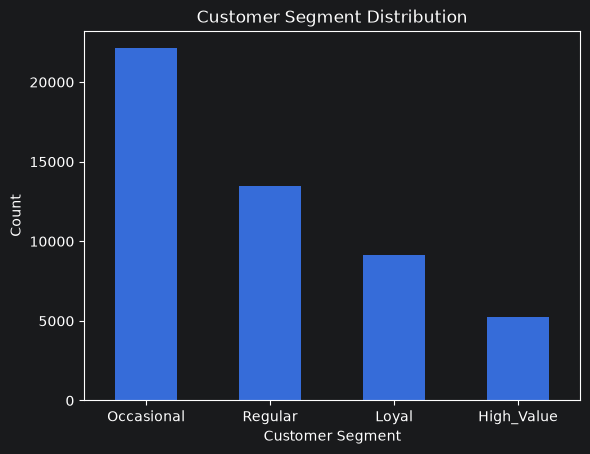

In [66]:
df["customer_segment"].value_counts().plot(kind="bar")

plt.title("Customer Segment Distribution")
plt.xlabel("Customer Segment")
plt.ylabel("Count")
plt.xticks(rotation=0)
plt.show()

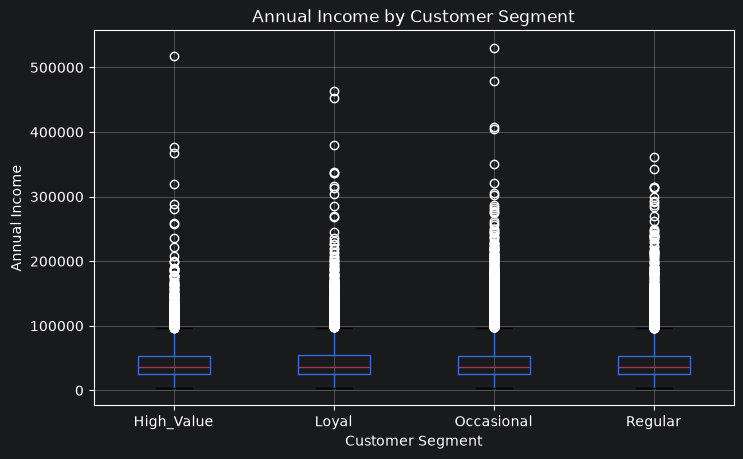

In [67]:
df.boxplot(
    column="annual_income",
    by="customer_segment",
    figsize=(8, 5)
)

plt.title("Annual Income by Customer Segment")
plt.suptitle("")
plt.xlabel("Customer Segment")
plt.ylabel("Annual Income")
plt.show()

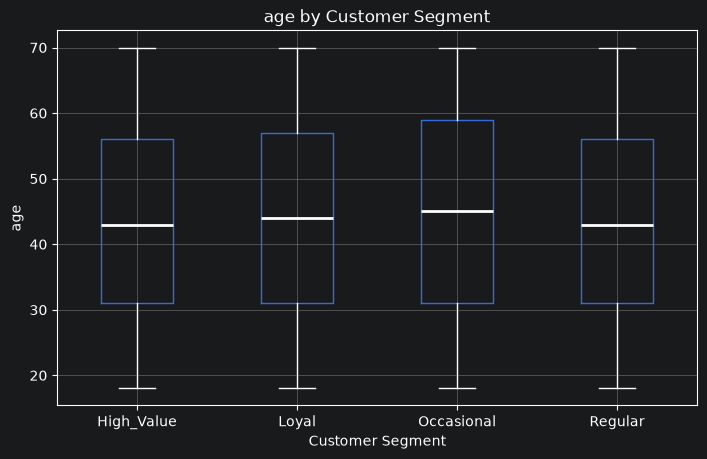

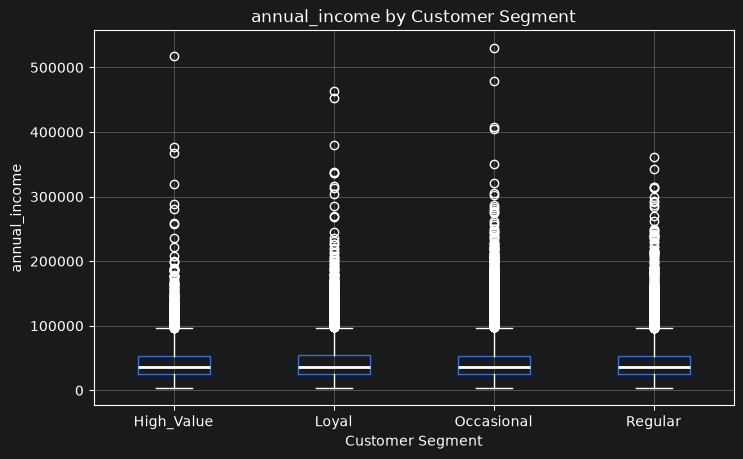

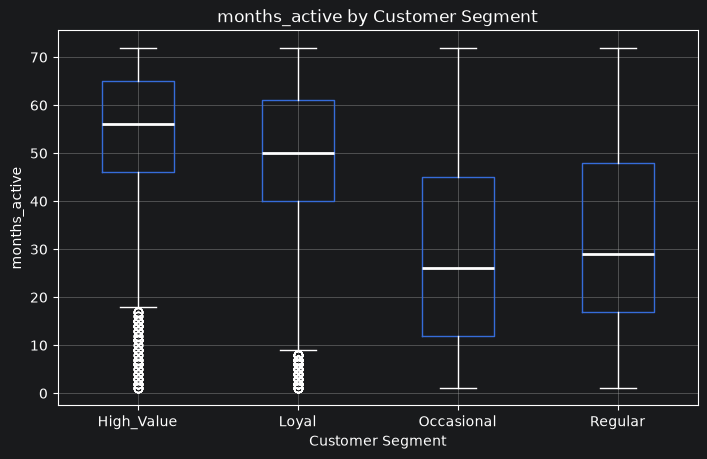

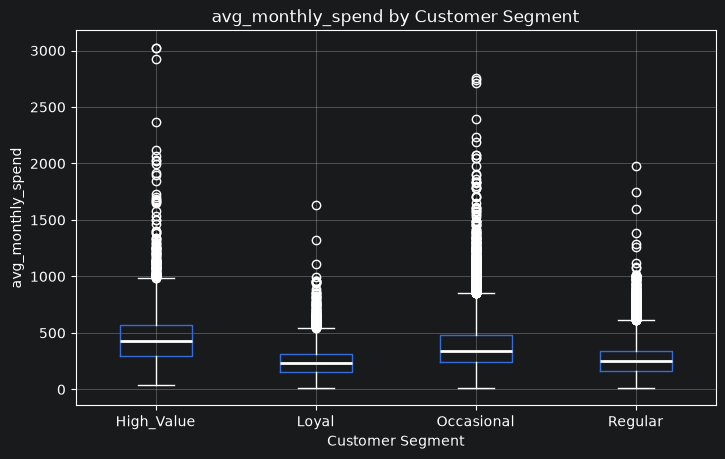

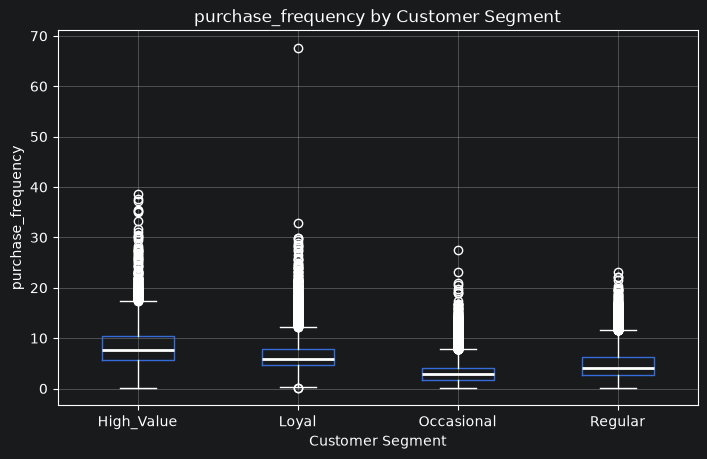

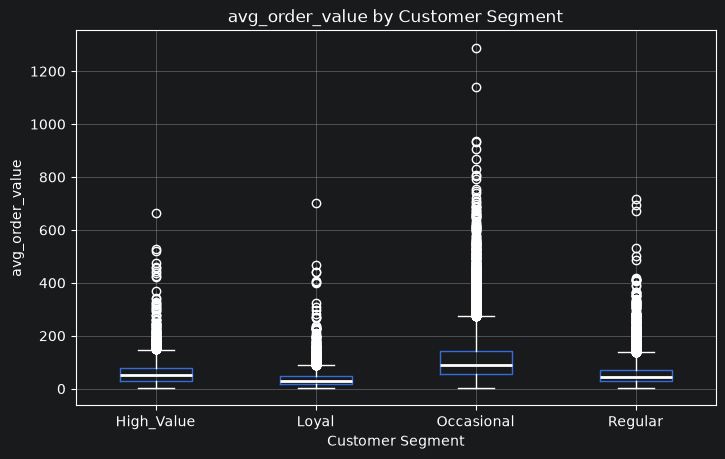

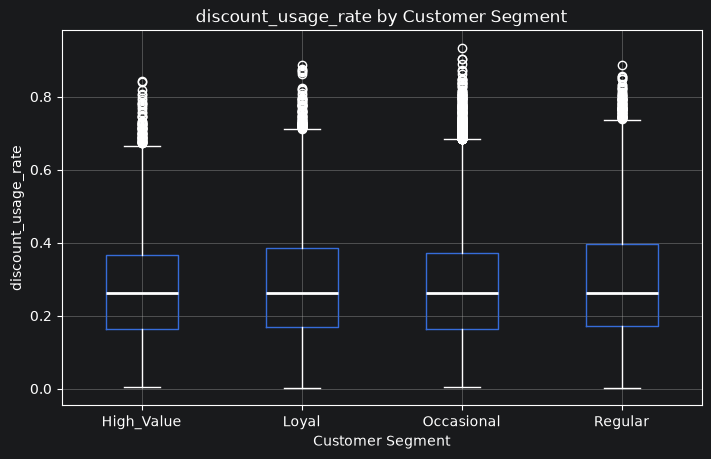

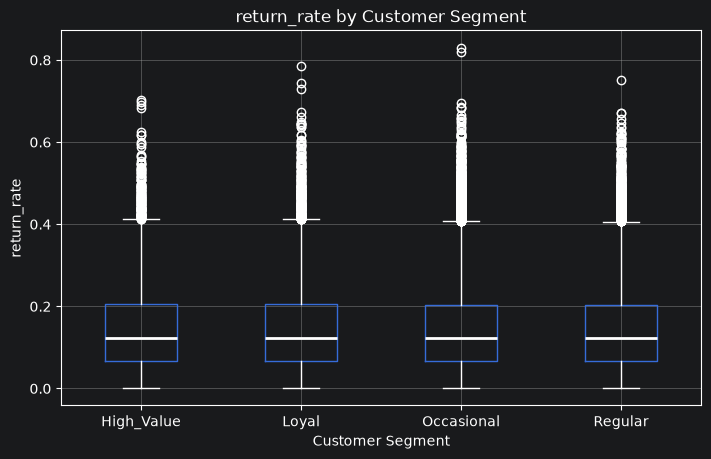

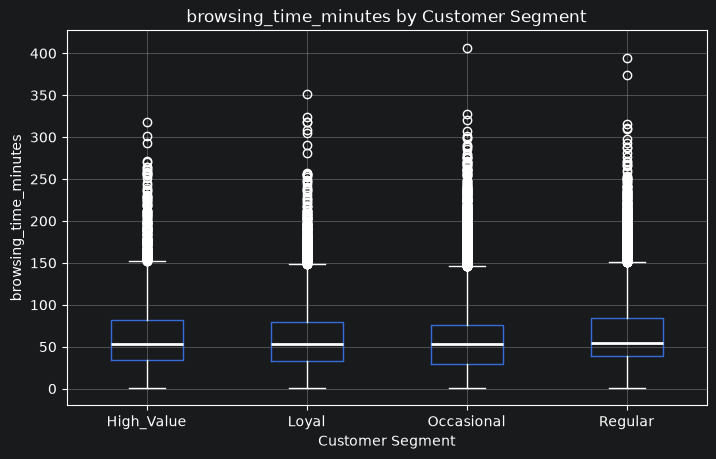

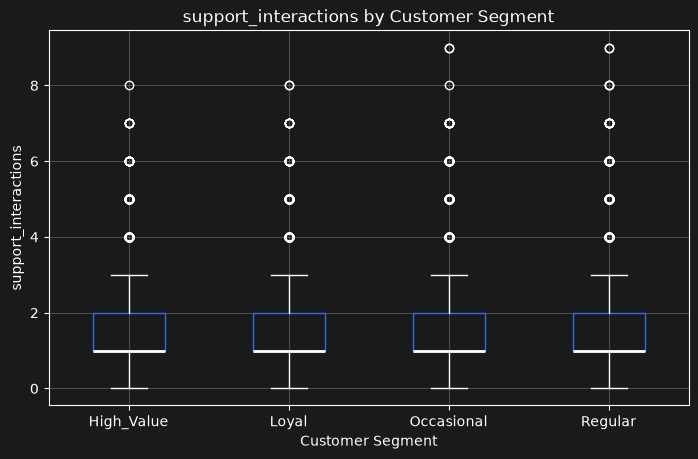

In [74]:
numeric_cols = [
    "age",
    "annual_income",
    "months_active",
    "avg_monthly_spend",
    "purchase_frequency",
    "avg_order_value",
    "discount_usage_rate",
    "return_rate",
    "browsing_time_minutes",
    "support_interactions"
]

for col in numeric_cols:
    df.boxplot(
        column=col,
        by="customer_segment",
        figsize=(8, 5),
        whiskerprops=dict(color="white"),
        capprops=dict(color="white"),
        medianprops=dict(color="white", linewidth=2)
    )

    plt.title(f"{col} by Customer Segment")
    plt.suptitle("")
    plt.xlabel("Customer Segment")
    plt.ylabel(col)
    plt.show()

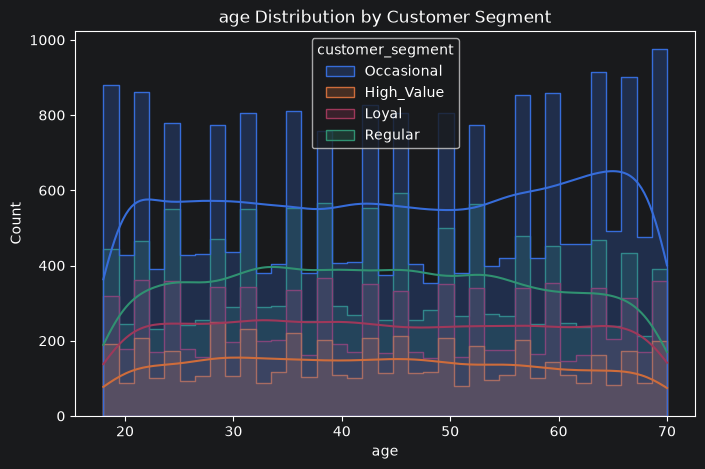

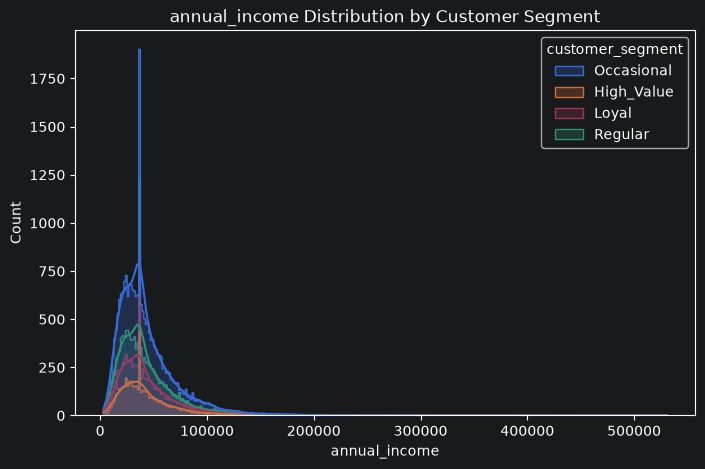

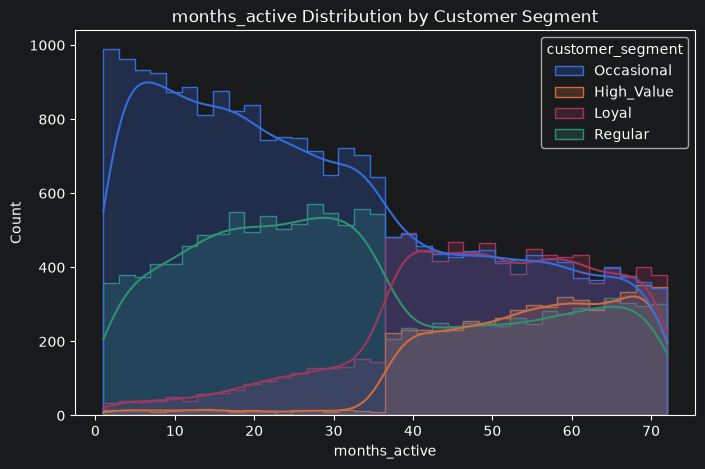

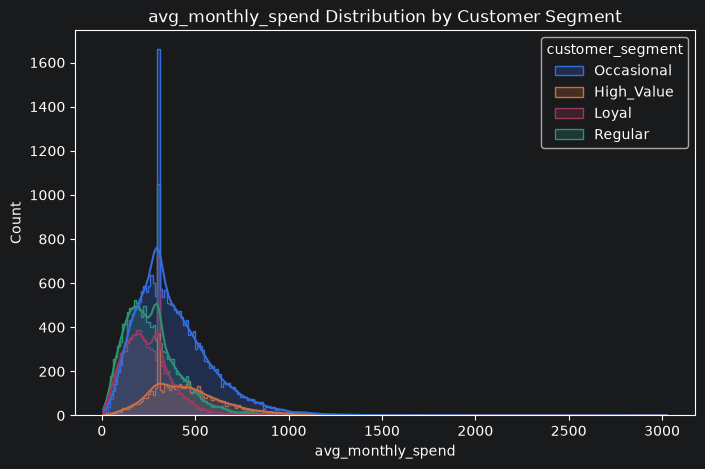

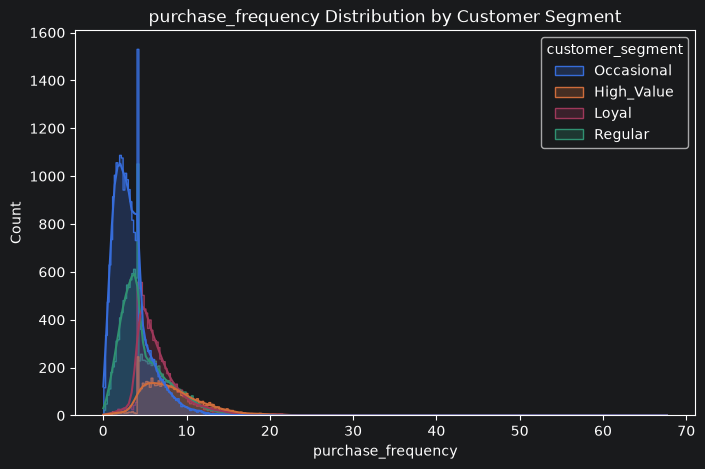

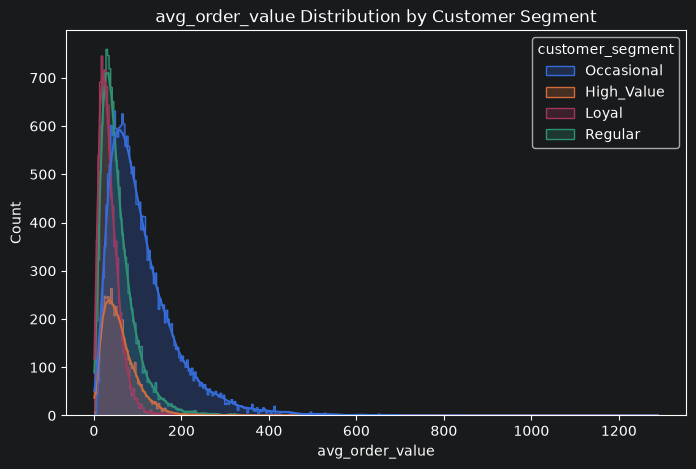

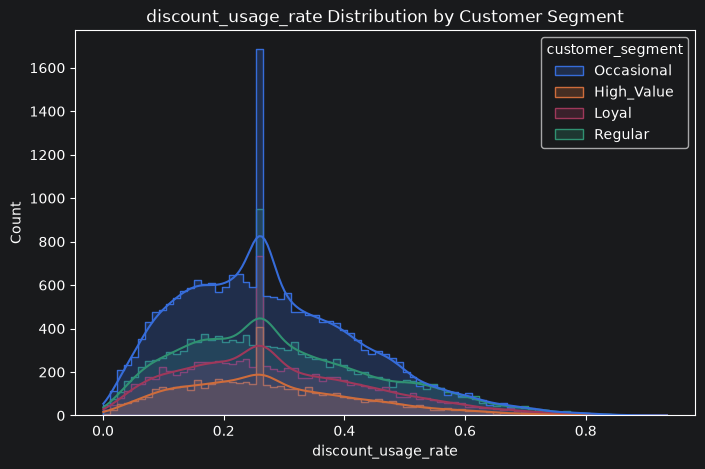

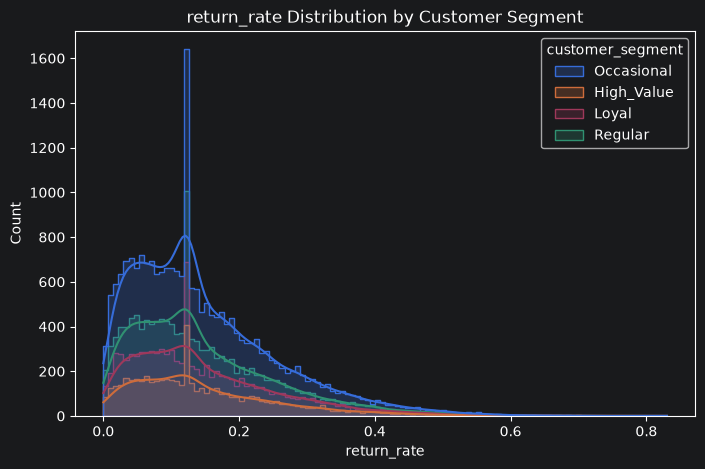

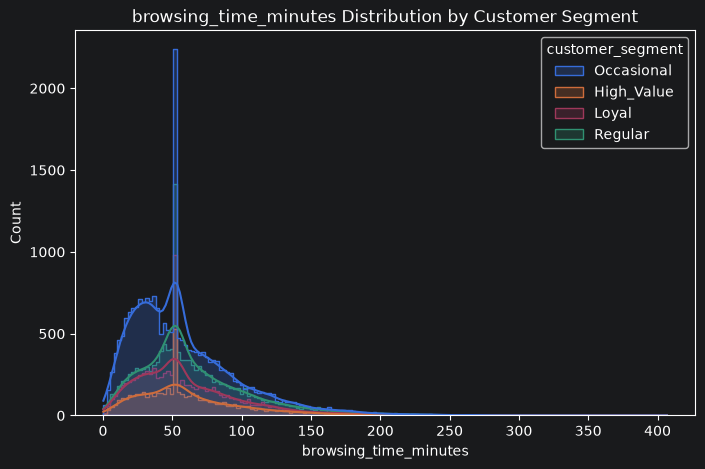

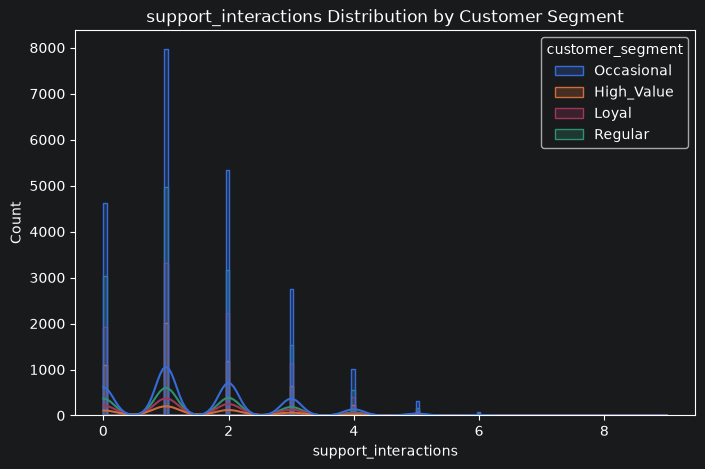

In [71]:
for col in numeric_cols:
    plt.figure(figsize=(8, 5))

    sns.histplot(
        data=df,
        x=col,
        hue="customer_segment",
        kde=True,
        element="step"
    )

    plt.title(f"{col} Distribution by Customer Segment")
    plt.show()

In [76]:
numeric_cols = df.select_dtypes(include="number").columns

df[numeric_cols].skew().sort_values(ascending=False)

avg_order_value          2.829497
annual_income            2.743968
avg_monthly_spend        1.822820
purchase_frequency       1.796838
browsing_time_minutes    1.450708
return_rate              1.180747
support_interactions     0.884035
discount_usage_rate      0.646260
age                      0.008991
months_active            0.003569
dtype: float64

In [77]:
df["annual_income"].describe(
    percentiles=[0.01, 0.05, 0.25, 0.5, 0.75, 0.95, 0.99]
)

count     50000.000000
mean      44065.695114
std       29642.592692
min        2946.317892
1%         9281.433938
5%        13920.502215
25%       25112.704208
50%       36787.730010
75%       53830.215138
95%       99390.227116
99%      152879.751713
max      530788.317921
Name: annual_income, dtype: float64

In [78]:
for col in numeric_cols:
    print(f"\n--- {col} ---")

    print("Min:", df[col].min())
    print("Median:", df[col].median())
    print("95%:", df[col].quantile(0.95))
    print("99%:", df[col].quantile(0.99))
    print("Max:", df[col].max())


--- age ---
Min: 18
Median: 44.0
95%: 68.0
99%: 70.0
Max: 70

--- annual_income ---
Min: 2946.317892127992
Median: 36787.73001021955
95%: 99390.22711598623
99%: 152879.75171321887
Max: 530788.3179208386

--- months_active ---
Min: 1
Median: 36.0
95%: 69.0
99%: 72.0
Max: 72

--- avg_monthly_spend ---
Min: 8.072297826133191
Median: 297.4774037479535
95%: 703.6659474479095
99%: 973.6576606416182
Max: 3026.342238332375

--- purchase_frequency ---
Min: 0.017013073688397
Median: 4.1586729128523325
95%: 11.231383345692192
99%: 15.872103963808353
Max: 67.68252770998417

--- avg_order_value ---
Min: 0.9403927647950402
Median: 56.600350821648945
95%: 210.78116003808606
99%: 343.6911611868876
Max: 1289.4273277608377

--- discount_usage_rate ---
Min: 0.0005339624298327
Median: 0.2625905388320229
95%: 0.575655046992695
99%: 0.70305368901438
Max: 0.9346547455517108

--- return_rate ---
Min: 4.96825035441816e-05
Median: 0.1236282170416951
95%: 0.36183455938893255
99%: 0.48459415478053264
Max: 0.8303

In [79]:
df["annual_income_log"] = np.log1p(df["annual_income"])

In [80]:
df["annual_income_log"]

0        11.517656
1        10.910197
2        10.972828
3        11.079536
4        10.219483
           ...    
49995    10.534389
49996    11.087036
49997    11.136037
49998    10.512947
49999     9.846490
Name: annual_income_log, Length: 50000, dtype: float64

In [81]:
df["annual_income_log"].skew()

0.043060043237653674

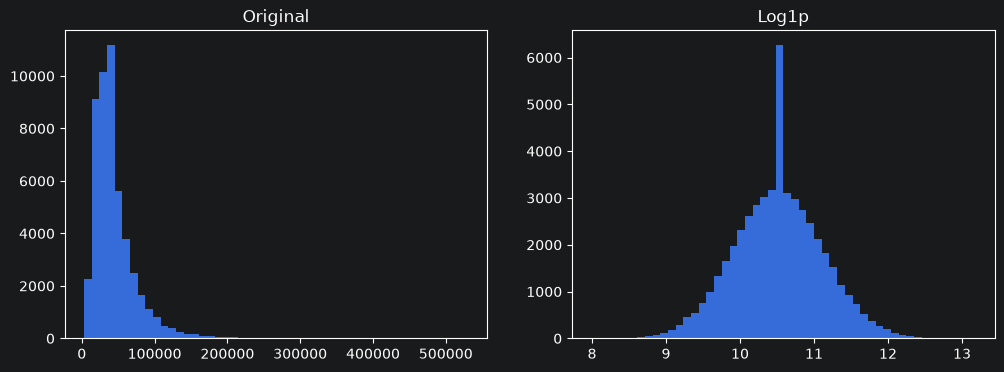

In [84]:
fig, ax = plt.subplots(1, 2, figsize=(12, 4))

ax[0].hist(df["annual_income"], bins=50)
ax[0].set_title("Original")

ax[1].hist(np.log1p(df["annual_income"]), bins=50)
ax[1].set_title("Log1p")

plt.show()

In [86]:
df.columns

Index(['age', 'annual_income', 'months_active', 'avg_monthly_spend',
       'purchase_frequency', 'avg_order_value', 'discount_usage_rate',
       'return_rate', 'browsing_time_minutes', 'support_interactions',
       'payment_method', 'region', 'customer_segment', 'annual_income_log'],
      dtype='str')

In [89]:
df.drop("annual_income_log",axis=1, inplace=True)

In [90]:
df.columns

Index(['age', 'annual_income', 'months_active', 'avg_monthly_spend',
       'purchase_frequency', 'avg_order_value', 'discount_usage_rate',
       'return_rate', 'browsing_time_minutes', 'support_interactions',
       'payment_method', 'region', 'customer_segment'],
      dtype='str')

In [91]:
X = df[["age","annual_income","months_active","avg_monthly_spend","purchase_frequency","avg_order_value","discount_usage_rate","return_rate","browsing_time_minutes","support_interactions","payment_method","region"]].values
y = df["customer_segment"].values

In [92]:
y

<StringArray>
['Occasional', 'Occasional', 'Occasional', 'High_Value', 'Occasional',
 'Occasional', 'Occasional', 'Occasional', 'Occasional', 'High_Value',
 ...
 'Occasional', 'Occasional', 'Occasional', 'Occasional',      'Loyal',
    'Regular', 'High_Value', 'High_Value',    'Regular',    'Regular']
Length: 50000, dtype: str

In [98]:
X[0]

array([53, 100473.21170893354, 63, 121.43056506459864, 0.8172677727505312,
       66.82040307180874, 0.1172560325657158, 0.0231439770726946,
       77.29839307918124, 2.0, 'Card', 'Semi-Urban'], dtype=object)

In [100]:
X = df.drop(columns=["customer_segment"]).copy()
y = df["customer_segment"].copy()

In [101]:
print(X.columns)

Index(['age', 'annual_income', 'months_active', 'avg_monthly_spend',
       'purchase_frequency', 'avg_order_value', 'discount_usage_rate',
       'return_rate', 'browsing_time_minutes', 'support_interactions',
       'payment_method', 'region'],
      dtype='str')


In [102]:
numeric_cols = X.select_dtypes(include="number").columns

categorical_cols = X.select_dtypes(
    include=["object", "string"]
).columns

In [104]:
print("Numeric:", numeric_cols.tolist())
print("Categorical:", categorical_cols.tolist())

Numeric: ['age', 'annual_income', 'months_active', 'avg_monthly_spend', 'purchase_frequency', 'avg_order_value', 'discount_usage_rate', 'return_rate', 'browsing_time_minutes', 'support_interactions']
Categorical: ['payment_method', 'region']


In [131]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=1453,
    stratify=y
)

In [132]:
from sklearn.preprocessing import LabelEncoder

target_encoder = LabelEncoder()

y_train = target_encoder.fit_transform(y_train)
y_test = target_encoder.transform(y_test)

In [133]:
print(target_encoder.classes_)

['High_Value' 'Loyal' 'Occasional' 'Regular']


In [134]:
y_train

array([1, 2, 0, ..., 2, 1, 3])

In [135]:
log_cols = [
    "annual_income",
    "avg_monthly_spend",
    "purchase_frequency",
    "avg_order_value",
    "browsing_time_minutes"
]
for col in log_cols:
    X_train[col] = np.log1p(X_train[col])
    X_test[col] = np.log1p(X_test[col])

In [136]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_numeric = scaler.fit_transform(
    X_train[numeric_cols]
)



X_test_numeric = scaler.transform(
    X_test[numeric_cols]
)

In [137]:
from sklearn.preprocessing import OneHotEncoder

encoder = OneHotEncoder(
    handle_unknown="ignore",
    sparse_output=False
)

X_train_cat = encoder.fit_transform(
    X_train[categorical_cols]
)



X_test_cat = encoder.transform(
    X_test[categorical_cols]
)

In [138]:
X_train = np.hstack([
    X_train_numeric,
    X_train_cat
])


X_test = np.hstack([
    X_test_numeric,
    X_test_cat
])

In [139]:
print(X_train.shape)
print(X_test.shape)

(40000, 16)
(10000, 16)


In [140]:
import torch

X_train = torch.tensor(
    X_train,
    dtype=torch.float32
)



X_test = torch.tensor(
    X_test,
    dtype=torch.float32
)

y_train = torch.tensor(
    y_train,
    dtype=torch.long
)



y_test = torch.tensor(
    y_test,
    dtype=torch.long
)

In [142]:
print("X_train:", X_train.shape)
print("X_test:", X_test.shape)

print("y_train:", y_train.shape)
print("y_test:", y_test.shape)

X_train: torch.Size([40000, 16])
X_test: torch.Size([10000, 16])
y_train: torch.Size([40000])
y_test: torch.Size([10000])


In [143]:
print(X_train.dtype)
print(y_train.dtype)

torch.float32
torch.int64


In [144]:
print("NaN:", torch.isnan(X_train).any())
print("Inf:", torch.isinf(X_train).any())

NaN: tensor(False)
Inf: tensor(False)


In [145]:
print(torch.unique(y_train))

tensor([0, 1, 2, 3])


In [146]:
print(target_encoder.classes_)

['High_Value' 'Loyal' 'Occasional' 'Regular']


In [147]:
print(encoder.categories_)

[array(['Card', 'UPI', 'Wallet'], dtype=object), array(['Rural', 'Semi-Urban', 'Urban'], dtype=object)]


In [148]:
print(
    encoder.get_feature_names_out(categorical_cols)
)

['payment_method_Card' 'payment_method_UPI' 'payment_method_Wallet'
 'region_Rural' 'region_Semi-Urban' 'region_Urban']


In [149]:
print(
    X_train_numeric.mean(axis=0)
)

[-1.35003120e-17  3.00381942e-16 -4.60076421e-17 -8.12705458e-16
 -1.04272146e-16  4.31477076e-16  2.22755148e-16  2.26663133e-16
 -1.30251365e-16  1.05160325e-16]


In [150]:
print(
    X_train_numeric.std(axis=0)
)

[1. 1. 1. 1. 1. 1. 1. 1. 1. 1.]


In [151]:
for col in log_cols:
    print(col, df[col].min())

annual_income 2946.317892127992
avg_monthly_spend 8.072297826133191
purchase_frequency 0.017013073688397
avg_order_value 0.9403927647950402
browsing_time_minutes 0.2361091210276837


In [152]:
X_train.shape[0] == y_train.shape[0]

True

In [154]:
assert X_train.shape[0] == y_train.shape[0]
assert X_test.shape[0] == y_test.shape[0]

assert not torch.isnan(X_train).any()
assert not torch.isinf(X_train).any()
assert y_train.dtype == torch.long
assert X_train.dtype == torch.float32

print("All preprocessing checks passed.")

All preprocessing checks passed.


In [160]:
print(X_train.shape), len(torch.unique(y_train))

torch.Size([40000, 16])


(None, 4)

In [161]:
from torch import nn
class ORCSClassifier(nn.Module):
    def __init__(self):
        super().__init__()
        self.linear_layer_stack = nn.Sequential(
            nn.Linear(16, 64),
            nn.ReLU(),
            nn.Linear(64, 64),
            nn.ReLU(),
            nn.Linear(64,32),
            nn.ReLU(),
            nn.Linear(32,16),
            nn.ReLU(),
            nn.Linear(16,4),

        )
    def forward(self,x):
        return self.linear_layer_stack(x)